# EEG_20 — DHSLP Cluster-Specifico: Due Modelli per Due Fenotipi

## Motivazione

Da **EEG_16b** sappiamo che i 73 soggetti si dividono in due fenotipi di connettività
strutturale stabili e robusti (ARI cross-metrica >= 0.95):

- **C0 — Fronto-motor** (~36 soggetti): connettività dominante nelle aree fronto-centrali
  destre (F2-FT7, F2-F8). Compatibile con imagery motorio-articolatorio.
- **C1 — Fronto-occipital** (~37 soggetti): connettività dominante nel network
  fronto-occipitale sinistro + link cross-emisferico F3<->PO8. Compatibile con
  imagery visuo-linguistico.

## Ipotesi

Il modello DHSLP soggetto-indipendente standard impara iperedge che sono un
**compromesso** tra C0 e C1. Un modello addestrato solo su soggetti C0 dovrebbe
convergere su iperedge fronto-centrali; idem C1.

**Ipotesi**: i modelli cluster-specifici performano meglio dei modelli general-purpose
all'interno del proprio fenotipo, perche non devono mediare tra strutture incompatibili.

## Validazione preliminare (§3)

Prima di trainare, verificare che il pattern XAI (F3-PO8 per C1, F2-FT7 per C0) sia
visibile a livello di singolo soggetto — non solo sulla media del cluster.

## Design sperimentale

```
Soggetti C0 -> split C0_TRAIN/C0_VAL/C0_TEST (70/15/15)
Soggetti C1 -> split C1_TRAIN/C1_VAL/C1_TEST (70/15/15)

Model_C0: train su C0_TRAIN, val su C0_VAL, test su C0_TEST
Model_C1: train su C1_TRAIN, val su C1_VAL, test su C1_TEST

Evaluation:
  bAcc per soggetto test (tutte le sessioni)
  -> mean_bAcc_C0
  -> mean_bAcc_C1
  -> mean_bAcc_TOT
```


## §1 — Imports e Config

In [3]:
import json, logging, re, traceback
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import balanced_accuracy_score
from tqdm.auto import tqdm
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg20')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'eeg20'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── CONFIG DHSLP (identico a EEG_13b) ──
N_CHANNELS   = 61
N_SAMPLES    = 384
N_CLASSES    = 4
CLUSTER_SCHEME = 'concr4'

K_WINDOWS  = 8
N_EDGES    = 32
D_MODEL    = 64
HIDDEN     = 256
N_LAYERS   = 2
DROPOUT    = 0.3

LR               = 1e-3
WEIGHT_DECAY     = 3e-3
GRAD_CLIP        = 1.0
BATCH_SIZE       = 32
MAX_EPOCHS       = 150
PATIENCE         = 25
LABEL_SMOOTHING  = 0.1
USE_INSTANCE_NORM = True

USE_AUGMENTATION = True
AUG_NOISE_STD    = 0.05
AUG_AMP_RANGE    = (0.85, 1.15)
AUG_SHIFT_MAX    = 15
AUG_MASK_LEN     = 20

DATA_METRIC = 'abs_pcc'

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

T_WIN = N_SAMPLES // K_WINDOWS

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k,v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
log.info(f'Device: {device}  T_WIN={T_WIN}')


14:23:24 INFO     Device: cuda  T_WIN=48


## §2 — Carica Cluster Labels da EEG_16b

Carica il file JSON salvato da **§22 di EEG_16b**.
Se non esiste ancora, esegui §22 di EEG_16b e poi torna qui.


In [4]:
labels_path = project_root / 'configs' / 'eeg16b_cluster_labels.json'
assert labels_path.exists(), f'Esegui §22 di EEG_16b prima! File mancante: {labels_path}'

cluster_data  = json.loads(labels_path.read_text())
SUBJ_ALL      = cluster_data['subj_ids']
LABELS_ALL    = cluster_data['labels']
# JSON keys sono stringhe — converti a lista indicizzabile per intero
_cn = cluster_data['cluster_names']
CLUSTER_NAMES = [_cn[str(i)] for i in range(len(_cn))] if isinstance(_cn, dict) else list(_cn)

C0_SUBJS = sorted([s for s,l in zip(SUBJ_ALL,LABELS_ALL) if l==0])
C1_SUBJS = sorted([s for s,l in zip(SUBJ_ALL,LABELS_ALL) if l==1])

log.info(f'C0 ({CLUSTER_NAMES[0]}): {len(C0_SUBJS)} soggetti')
log.info(f'C1 ({CLUSTER_NAMES[1]}): {len(C1_SUBJS)} soggetti')

def split_cluster(subjs, seed=42):
    rng = np.random.default_rng(seed)
    subjs = list(rng.permutation(subjs))
    n = len(subjs)
    n_train = int(n * 0.70)
    n_val   = int(n * 0.15)
    return subjs[:n_train], subjs[n_train:n_train+n_val], subjs[n_train+n_val:]

C0_TRAIN, C0_VAL, C0_TEST = split_cluster(C0_SUBJS)
C1_TRAIN, C1_VAL, C1_TEST = split_cluster(C1_SUBJS)

log.info(f'C0 split: train={len(C0_TRAIN)}  val={len(C0_VAL)}  test={len(C0_TEST)}')
log.info(f'C1 split: train={len(C1_TRAIN)}  val={len(C1_VAL)}  test={len(C1_TEST)}')


14:23:24 INFO     C0 (Fronto-motor): 36 soggetti
14:23:24 INFO     C1 (Fronto-occipital): 37 soggetti
14:23:24 INFO     C0 split: train=25  val=5  test=6
14:23:24 INFO     C1 split: train=25  val=5  test=7


## §3 — Validazione: il Pattern XAI e Individuale?

Verifica che F3-PO8 (C1) e F2-FT7 (C0) siano separati a livello di singolo soggetto.
**Richiede**: `FEAT_G`, `LABELS_H`, `CHAN_NAMES` in memoria da EEG_16b, oppure
il cache NPZ in `models/eeg16b/feat_graph_abs_pcc.npz`.


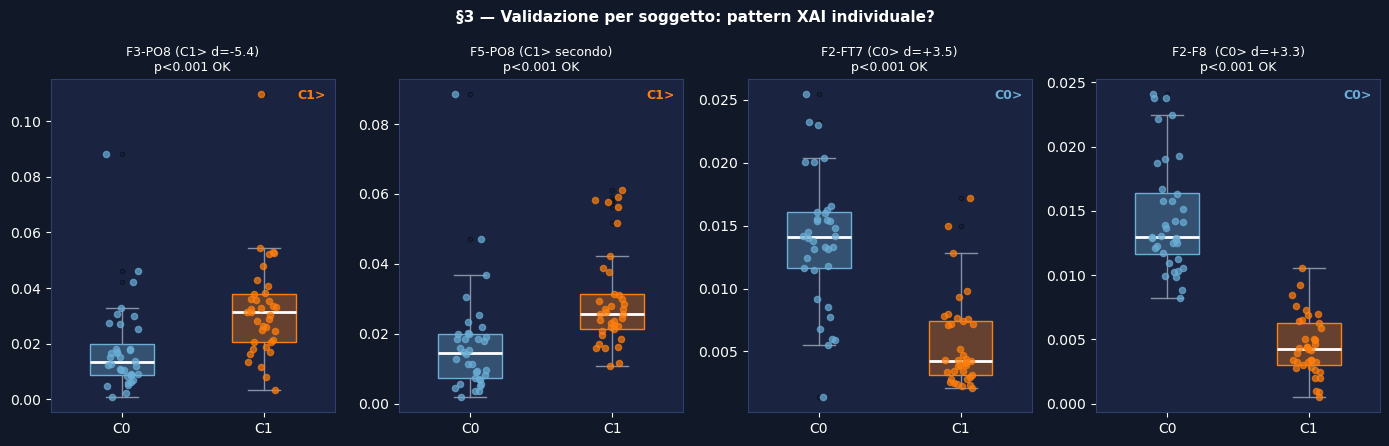


Verde per EEG_20


In [5]:
from scipy.stats import mannwhitneyu

CKPT_16B = project_root / 'models' / 'eeg16b'

# Carica feature da cache se non gia in memoria
if 'FEAT_G' not in dir() or 'CHAN_NAMES' not in dir():
    cache_g = CKPT_16B / 'feat_graph_abs_pcc.npz'
    assert cache_g.exists(), f'Cache non trovata: {cache_g}. Esegui EEG_16b §1.'
    d = np.load(cache_g, allow_pickle=True)
    FEAT_G = d['feat']
    _subj_g = list(d['subj_ids'])
    CHAN_NAMES = list(d['chan_names'])
    # Allinea labels con FEAT_G
    LABELS_H = np.array([cluster_data['labels'][cluster_data['subj_ids'].index(s)]
                         if s in cluster_data['subj_ids'] else -1 for s in _subj_g])

rows_tri, cols_tri = np.triu_indices(61, k=1)
def pair_idx(a, b):
    ia,ib = CHAN_NAMES.index(a), CHAN_NAMES.index(b)
    i,j = min(ia,ib), max(ia,ib)
    return int(np.where((rows_tri==i)&(cols_tri==j))[0][0])

c0m = (np.array(LABELS_H)==0)
c1m = (np.array(LABELS_H)==1)

PAIRS = [
    ('F3','PO8','F3-PO8 (C1> d=-5.4)','C1>'),
    ('F5','PO8','F5-PO8 (C1> secondo)','C1>'),
    ('F2','FT7','F2-FT7 (C0> d=+3.5)','C0>'),
    ('F2','F8', 'F2-F8  (C0> d=+3.3)','C0>'),
]

C0C,C1C = '#6baed6','#ff7f0e'
fig,axes = plt.subplots(1,4,figsize=(14,4.5))
fig.patch.set_facecolor('#111827')
all_ok = True

for ax,(a,b,lbl,dom) in zip(axes,PAIRS):
    v0,v1 = FEAT_G[c0m,pair_idx(a,b)], FEAT_G[c1m,pair_idx(a,b)]
    _,p = mannwhitneyu(v0,v1,alternative='two-sided')
    obs = 'C1>' if np.median(v1)>np.median(v0) else 'C0>'
    match = obs==dom
    if not match: all_ok=False
    bp = ax.boxplot([v0,v1],patch_artist=True,widths=0.45,
                   medianprops=dict(color='white',linewidth=2),
                   whiskerprops=dict(color='#8892a4'),capprops=dict(color='#8892a4'),
                   flierprops=dict(marker='o',markersize=3,alpha=0.4))
    bp['boxes'][0].set_facecolor(C0C+'55'); bp['boxes'][0].set_edgecolor(C0C)
    bp['boxes'][1].set_facecolor(C1C+'55'); bp['boxes'][1].set_edgecolor(C1C)
    rng=np.random.default_rng(42)
    for vals,x,col in [(v0,1,C0C),(v1,2,C1C)]:
        ax.scatter(x+rng.uniform(-0.12,0.12,len(vals)),vals,color=col,alpha=0.7,s=20,zorder=3)
    ps = 'p<0.001' if p<0.001 else f'p={p:.3f}'
    tick = 'OK' if match else 'INVERSO'
    ec = C1C if dom=='C1>' else C0C
    ax.set_facecolor('#1a2340')
    ax.set_xticks([1,2]); ax.set_xticklabels(['C0','C1'],color='white',fontsize=10)
    ax.tick_params(colors='white')
    ax.set_title(f'{lbl}\n{ps} {tick}',color='white',fontsize=9)
    for sp in ax.spines.values(): sp.set_color('#2e3f6e')
    ax.text(0.97,0.97,dom,transform=ax.transAxes,color=ec,fontsize=9,ha='right',va='top',fontweight='bold')

fig.suptitle('§3 — Validazione per soggetto: pattern XAI individuale?',color='white',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'eeg20_validation_persubj.png',dpi=150,bbox_inches='tight',facecolor='#111827')
plt.show()
print('\nVerde per EEG_20' if all_ok else '\nAttenzione: alcune coppie invertite!')


## §4 — Dataset Multi-Soggetto (Subject-Independent)

In [6]:
def _augment(x):
    x = x.clone()
    if torch.rand(1)<0.5: x = x + torch.randn_like(x)*AUG_NOISE_STD
    if torch.rand(1)<0.5: x = x * torch.empty(1).uniform_(*AUG_AMP_RANGE)
    if torch.rand(1)<0.5:
        s = torch.randint(-AUG_SHIFT_MAX,AUG_SHIFT_MAX+1,(1,)).item()
        x = torch.roll(x,s,dims=1)
    if torch.rand(1)<0.3:
        T=x.shape[1]; st=torch.randint(0,max(1,T-AUG_MASK_LEN),(1,)).item()
        x[:,st:st+AUG_MASK_LEN]=0.
    return x


class EEGMultiSubjDataset(Dataset):
    def __init__(self, subj_list, augment=False):
        self.augment=augment; self.trials=[]; self.labels=[]
        HG = project_root/'data'/f'hypergraphs_pruned_{DATA_METRIC}'
        for sid in subj_list:
            for sd in sorted(HG.glob(f'P{sid:03d}_S*')):
                for pt in sorted(sd.glob('trial_*.pt')):
                    t=torch.load(pt,map_location='cpu',weights_only=False)
                    yc=label2cluster.get(int(t['y']),-1)
                    if yc<0: continue
                    self.trials.append(pt); self.labels.append(yc)
        log.info(f'Dataset {len(subj_list)} sogg -> {len(self.trials)} trial')

    def __len__(self): return len(self.trials)

    def __getitem__(self,idx):
        t=torch.load(self.trials[idx],map_location='cpu',weights_only=False)
        x=t['x'].float()
        if USE_INSTANCE_NORM:
            x=(x-x.mean(-1,keepdim=True))/(x.std(-1,keepdim=True)+1e-6)
        if self.augment: x=_augment(x)
        return x,torch.tensor(self.labels[idx],dtype=torch.long)


def make_loaders(tr_s,va_s,te_s):
    return (DataLoader(EEGMultiSubjDataset(tr_s,augment=True), BATCH_SIZE,shuffle=True, num_workers=0,drop_last=True),
            DataLoader(EEGMultiSubjDataset(va_s,augment=False),BATCH_SIZE,shuffle=False,num_workers=0),
            DataLoader(EEGMultiSubjDataset(te_s,augment=False),BATCH_SIZE,shuffle=False,num_workers=0))


## §5 — Modello DHSLP (identico a EEG_13b)

In [7]:
class HGNNConv(nn.Module):
    def __init__(self,in_ch,out_ch,bias=True):
        super().__init__()
        self.weight=nn.Parameter(torch.empty(in_ch,out_ch))
        self.bias=nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)
    def forward(self,X,H):
        dv=H.sum(2).clamp(1e-6); de=H.sum(1).clamp(1e-6)
        Dv=(1./dv.sqrt()).unsqueeze(-1); De=(1./de).unsqueeze(1)
        out=Dv*(X@self.weight)
        out=torch.bmm(H.transpose(1,2),out)
        out=De.transpose(1,2)*out
        out=torch.bmm(H,out)
        out=Dv*out
        if self.bias is not None: out=out+self.bias
        return out


class DHSLP(nn.Module):
    def __init__(self,n_nodes=N_CHANNELS,T_win=T_WIN,K=K_WINDOWS,
                 n_edges=N_EDGES,d_model=D_MODEL,hidden=HIDDEN,
                 n_classes=N_CLASSES,n_layers=N_LAYERS,dropout=DROPOUT):
        super().__init__()
        self.K,self.T_win,self.d_model=K,T_win,d_model
        self.E=nn.Parameter(torch.randn(n_edges,d_model)*0.01)
        self.pos_enc=nn.Parameter(torch.randn(n_nodes,d_model)*0.01)
        self.node_proj=nn.Sequential(nn.Linear(T_win,d_model),nn.LayerNorm(d_model),nn.ELU())
        dims=[d_model]+[hidden]*n_layers
        self.convs=nn.ModuleList([HGNNConv(dims[i],dims[i+1]) for i in range(n_layers)])
        self.bns=nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop=nn.Dropout(dropout)
        self.head=nn.Linear(hidden,n_classes)

    def forward(self,x):
        B,N,T=x.shape
        wins=x.reshape(B,N,self.K,self.T_win).permute(2,0,1,3)
        zs=[]
        for k in range(self.K):
            xk=wins[k]
            fk=self.node_proj(xk)+self.pos_enc.unsqueeze(0)
            Hk=torch.softmax(fk@self.E.T/(self.d_model**0.5),dim=-1)
            out=fk
            for conv,bn in zip(self.convs,self.bns):
                out=conv(out,Hk)
                out=bn(out.reshape(B*N,-1)).reshape(B,N,-1)
                out=F.elu(out); out=self.drop(out)
            zs.append(out.mean(1))
        return self.head(torch.stack(zs).mean(0))


## §6 — Train / Eval

In [8]:
_crit=nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def run_epoch(model,loader,opt=None):
    train=opt is not None
    model.train() if train else model.eval()
    loss_tot,yl,yp=0.,[],[]
    with (torch.enable_grad() if train else torch.no_grad()):
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            logits=model(x); loss=_crit(logits,y)
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP)
                opt.step()
            loss_tot+=loss.item()*len(y)
            yl.extend(y.cpu().numpy()); yp.extend(logits.argmax(1).cpu().numpy())
    return loss_tot/len(loader.dataset), balanced_accuracy_score(yl,yp), np.array(yl), np.array(yp)


def train_model(name, tr_l, va_l, ckpt_path):
    run=wandb.init(entity=WANDB_ENTITY,project=WANDB_PROJECT,name=f'eeg20_DHSLP_{name}',
                   config=dict(notebook='EEG_20',cluster=name,n_edges=N_EDGES,d_model=D_MODEL,
                               hidden=HIDDEN,dropout=DROPOUT,lr=LR,max_epochs=MAX_EPOCHS,
                               n_train=len(tr_l.dataset)),
                   reinit='finish_previous',settings=wandb.Settings(start_method='thread'))
    model=DHSLP().to(device)
    opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=MAX_EPOCHS,eta_min=LR/20)
    best,pat=0.,0
    for ep in range(1,MAX_EPOCHS+1):
        _,tr_b,_,_=run_epoch(model,tr_l,opt)
        _,va_b,_,_=run_epoch(model,va_l)
        sched.step()
        run.log({'train/bacc':tr_b,'val/bacc':va_b,'lr':sched.get_last_lr()[0],'epoch':ep})
        if va_b>best: best=va_b; pat=0; torch.save(model.state_dict(),ckpt_path)
        else:
            pat+=1
            if pat>=PATIENCE:
                log.info(f'{name} early stop ep={ep} best={best:.4f}'); break
        if ep%10==0: log.info(f'{name} ep={ep:3d} tr={tr_b:.3f} va={va_b:.3f} best={best:.3f}')
    run.summary['best_val_bacc']=best; run.finish()
    log.info(f'{name} DONE — best val bAcc={best:.4f}')
    return best


## §7 — Training Model_C0 e Model_C1

In [9]:
tr_c0,va_c0,te_c0 = make_loaders(C0_TRAIN,C0_VAL,C0_TEST)
tr_c1,va_c1,te_c1 = make_loaders(C1_TRAIN,C1_VAL,C1_TEST)

CKPT_C0 = CKPT_DIR/'model_c0_best.pt'
CKPT_C1 = CKPT_DIR/'model_c1_best.pt'

log.info('='*50)
log.info(f'Training Model_C0 ({CLUSTER_NAMES[0]}) su {len(C0_TRAIN)} sogg train')
best_c0 = train_model(f'C0_{CLUSTER_NAMES[0]}', tr_c0, va_c0, CKPT_C0)

log.info('='*50)
log.info(f'Training Model_C1 ({CLUSTER_NAMES[1]}) su {len(C1_TRAIN)} sogg train')
best_c1 = train_model(f'C1_{CLUSTER_NAMES[1]}', tr_c1, va_c1, CKPT_C1)

log.info(f'\nBest val — C0: {best_c0:.4f}  C1: {best_c1:.4f}')


14:23:30 INFO     Dataset 25 sogg -> 12920 trial
14:23:31 INFO     Dataset 5 sogg -> 2530 trial
14:23:33 INFO     Dataset 6 sogg -> 3114 trial
14:23:39 INFO     Dataset 25 sogg -> 13524 trial
14:23:40 INFO     Dataset 5 sogg -> 2530 trial
14:23:42 INFO     Dataset 7 sogg -> 3715 trial
14:23:42 INFO     ==================================================
14:23:42 INFO     Training Model_C0 (Fronto-motor) su 25 sogg train
wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


14:26:49 INFO     C0_Fronto-motor ep= 10 tr=0.250 va=0.250 best=0.252
14:29:49 INFO     C0_Fronto-motor ep= 20 tr=0.250 va=0.257 best=0.257
14:32:53 INFO     C0_Fronto-motor ep= 30 tr=0.250 va=0.250 best=0.257
14:35:50 INFO     C0_Fronto-motor ep= 40 tr=0.250 va=0.251 best=0.257
14:37:22 INFO     C0_Fronto-motor early stop ep=45 best=0.2569


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,██████████▇▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▁
train/bacc,█▂▃▃▄▃▂▁▃▂▃▃▄▂▁▂▄▂▁▂▂▂▁▂▂▃▃▄▂▂▁▃▂▅▃▂▄▃▄▆
val/bacc,▁▁▃▁▂▂▃▁▂▂▂▂▂▁▆▂▂█▂▂▂▂▂▁▂▂▁▁▂▂▂▂▂▂▂▃▂▂▂▂
best_val_bacc,0.25688
epoch,45
lr,0.0008
train/bacc,0.25147
val/bacc,0.25006


14:37:24 INFO     C0_Fronto-motor DONE — best val bAcc=0.2569
14:37:24 INFO     ==================================================
14:37:24 INFO     Training Model_C1 (Fronto-occipital) su 25 sogg train


14:40:30 INFO     C1_Fronto-occipital ep= 10 tr=0.250 va=0.250 best=0.250
14:43:48 INFO     C1_Fronto-occipital ep= 20 tr=0.250 va=0.250 best=0.250
14:45:41 INFO     C1_Fronto-occipital early stop ep=26 best=0.2504


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,██████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▃▃▂▂▂▁
train/bacc,▃▆▂█▁▅▂▂▂█▆▇▄▂▅▂▃▅▂▅▅▅▃▇▂▃
val/bacc,█▃▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▃▅▅▅▁▂▁▅▅
best_val_bacc,0.2504
epoch,26
lr,0.00093
train/bacc,0.24991
val/bacc,0.25


14:45:42 INFO     C1_Fronto-occipital DONE — best val bAcc=0.2504
14:45:42 INFO     
Best val — C0: 0.2569  C1: 0.2504


## §8 — Evaluation per Soggetto

14:45:42 INFO     Eval Model_C0 su C0_TEST (corretto)...


Eval C0->C0:   0%|          | 0/6 [00:00<?, ?it/s]

14:45:43 INFO     Eval Model_C0 su C1_TEST (cross)...


Eval C0->C1:   0%|          | 0/7 [00:00<?, ?it/s]

14:45:45 INFO     Eval Model_C1 su C0_TEST (cross)...


Eval C1->C0:   0%|          | 0/6 [00:00<?, ?it/s]

14:45:46 INFO     Eval Model_C1 su C1_TEST (corretto)...


Eval C1->C1:   0%|          | 0/7 [00:00<?, ?it/s]


  MATRICE 2x2 — bAcc media  (chance=0.250)
               Test C0           Test C1
  Model C0  0.2510 (OK)      0.2512 (cross)
  Model C1  0.2500 (cross)   0.2500 (OK)
  Diagonale (modello giusto):  C0=0.2510  C1=0.2500
  Fuori diag (modello sbagliato): C0on1=0.2512  C1on0=0.2500
  Specializzazione confermata: NO
  TOT bAcc=0.2505 (1.00x chance)  sogg>chance=15%


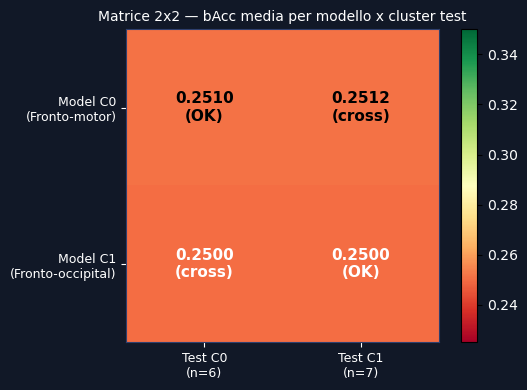

eval/C0_on_C0,▁
eval/C0_on_C1,▁
eval/C1_on_C0,▁
eval/C1_on_C1,▁
eval/mean_tot,▁
eval/specialization_confirmed,▁
eval/C0_on_C0,0.25102
eval/C0_on_C1,0.25121
eval/C1_on_C0,0.25
eval/C1_on_C1,0.25
eval/mean_tot,0.25047


Matrice 2x2 loggata su W&B.


In [10]:
def eval_per_subject(model, subj_list, name):
    """bAcc per singolo soggetto (tutte le sessioni)."""
    results = {}
    HG = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'
    model.eval()
    with torch.no_grad():
        for sid in tqdm(subj_list, desc=f'Eval {name}'):
            xs, ys = [], []
            for sd in sorted(HG.glob(f'P{sid:03d}_S*')):
                for pt in sorted(sd.glob('trial_*.pt')):
                    t  = torch.load(pt, map_location='cpu', weights_only=False)
                    yc = label2cluster.get(int(t['y']), -1)
                    if yc < 0: continue
                    x  = t['x'].float()
                    if USE_INSTANCE_NORM:
                        x = (x - x.mean(-1,keepdim=True)) / (x.std(-1,keepdim=True) + 1e-6)
                    xs.append(x); ys.append(yc)
            if not xs: continue
            preds = model(torch.stack(xs).to(device)).argmax(1).cpu().numpy()
            results[sid] = balanced_accuracy_score(ys, preds)
    return results


# Carica checkpoint
model_c0 = DHSLP().to(device)
model_c0.load_state_dict(torch.load(CKPT_C0, map_location=device))
model_c1 = DHSLP().to(device)
model_c1.load_state_dict(torch.load(CKPT_C1, map_location=device))

# ── Matrice 2x2: ogni modello su ogni gruppo di test subjects ───────────────
log.info('Eval Model_C0 su C0_TEST (corretto)...')
RES_C0_on_C0 = eval_per_subject(model_c0, C0_TEST, 'C0->C0')

log.info('Eval Model_C0 su C1_TEST (cross)...')
RES_C0_on_C1 = eval_per_subject(model_c0, C1_TEST, 'C0->C1')

log.info('Eval Model_C1 su C0_TEST (cross)...')
RES_C1_on_C0 = eval_per_subject(model_c1, C0_TEST, 'C1->C0')

log.info('Eval Model_C1 su C1_TEST (corretto)...')
RES_C1_on_C1 = eval_per_subject(model_c1, C1_TEST, 'C1->C1')

# Aliases per §9 e §10
RESULTS_C0 = RES_C0_on_C0
RESULTS_C1 = RES_C1_on_C1
all_res    = {**RESULTS_C0, **RESULTS_C1}

chance   = 1.0 / N_CLASSES
m_c0c0   = np.mean(list(RES_C0_on_C0.values()))
m_c0c1   = np.mean(list(RES_C0_on_C1.values()))
m_c1c0   = np.mean(list(RES_C1_on_C0.values()))
m_c1c1   = np.mean(list(RES_C1_on_C1.values()))
mean_c0  = m_c0c0
mean_c1  = m_c1c1
mean_tot = np.mean(list(all_res.values()))
pct      = sum(v > chance for v in all_res.values()) / len(all_res) * 100

# ── Stampa matrice 2x2 ──────────────────────────────────────────────────────
print(f'\n{"="*54}')
print(f'  MATRICE 2x2 — bAcc media  (chance={chance:.3f})')
print(f'{"="*54}')
print(f'               Test C0           Test C1')
print(f'  Model C0  {m_c0c0:.4f} (OK)      {m_c0c1:.4f} (cross)')
print(f'  Model C1  {m_c1c0:.4f} (cross)   {m_c1c1:.4f} (OK)')
print(f'{"="*54}')
print(f'  Diagonale (modello giusto):  C0={m_c0c0:.4f}  C1={m_c1c1:.4f}')
print(f'  Fuori diag (modello sbagliato): C0on1={m_c0c1:.4f}  C1on0={m_c1c0:.4f}')
diag_wins = (m_c0c0 > m_c1c0) and (m_c1c1 > m_c0c1)
print(f'  Specializzazione confermata: {"SI" if diag_wins else "NO"}')
print(f'{"="*54}')
print(f'  TOT bAcc={mean_tot:.4f} ({mean_tot/chance:.2f}x chance)  sogg>chance={pct:.0f}%')

# ── Plot matrice 2x2 ────────────────────────────────────────────────────────
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(5.5, 4))
fig.patch.set_facecolor('#111827')
ax.set_facecolor('#1a2340')

mat = np.array([[m_c0c0, m_c0c1],
                [m_c1c0, m_c1c1]])
im = ax.imshow(mat, cmap='RdYlGn', vmin=chance*0.9, vmax=max(mat.max(), chance*1.4))
plt.colorbar(im, ax=ax, fraction=0.04).ax.yaxis.set_tick_params(labelcolor='white')

labels_rows = [f'Model C0\n({CLUSTER_NAMES[0]})', f'Model C1\n({CLUSTER_NAMES[1]})']
labels_cols = [f'Test C0\n(n={len(C0_TEST)})', f'Test C1\n(n={len(C1_TEST)})']
ax.set_xticks([0,1]); ax.set_xticklabels(labels_cols, color='white', fontsize=9)
ax.set_yticks([0,1]); ax.set_yticklabels(labels_rows, color='white', fontsize=9)
ax.tick_params(colors='white')

for r in range(2):
    for c in range(2):
        tag = '(OK)' if r==c else '(cross)'
        color = 'black' if mat[r,c] > (mat.max()+mat.min())/2 else 'white'
        ax.text(c, r, f'{mat[r,c]:.4f}\n{tag}',
                ha='center', va='center', color=color, fontsize=11, fontweight='bold')

ax.set_title('Matrice 2x2 — bAcc media per modello x cluster test',
             color='white', fontsize=10)
for sp in ax.spines.values(): sp.set_color('#2e3f6e')
plt.tight_layout()
fig.savefig(FIG_DIR/'eeg20_matrix_2x2.png', dpi=150, bbox_inches='tight', facecolor='#111827')
plt.show()

# ── Log matrice su W&B nel run principale ───────────────────────────────────
run_matrix = wandb.init(
    entity=WANDB_ENTITY, project=WANDB_PROJECT,
    name='eeg20_2x2_eval_matrix',
    config=dict(notebook='EEG_20', section='eval_matrix',
                n_edges=N_EDGES, hidden=HIDDEN),
    reinit='finish_previous',
    settings=wandb.Settings(start_method='thread')
)
run_matrix.log({
    'eval/C0_on_C0': m_c0c0, 'eval/C0_on_C1': m_c0c1,
    'eval/C1_on_C0': m_c1c0, 'eval/C1_on_C1': m_c1c1,
    'eval/mean_tot': mean_tot,
    'eval/specialization_confirmed': int(diag_wins),
    'eval/matrix_image': wandb.Image(str(FIG_DIR/'eeg20_matrix_2x2.png')),
})

# Tabella per soggetto (tutte e 4 le combinazioni)
rows_subj = []
for sid in sorted(set(C0_TEST) | set(C1_TEST)):
    true_cl = 'C0' if sid in C0_TEST else 'C1'
    rows_subj.append({
        'Subject':   f'P{sid:03d}',
        'True_cluster': true_cl,
        'bAcc_correct_model': RES_C0_on_C0.get(sid, RES_C1_on_C1.get(sid, float('nan'))),
        'bAcc_wrong_model':   RES_C1_on_C0.get(sid, RES_C0_on_C1.get(sid, float('nan'))),
        'correct_wins': int(
            RES_C0_on_C0.get(sid, -1) > RES_C1_on_C0.get(sid, -1)
            if true_cl=='C0' else
            RES_C1_on_C1.get(sid, -1) > RES_C0_on_C1.get(sid, -1)
        ),
    })

df_subj = pd.DataFrame(rows_subj)
run_matrix.log({'eval/per_subject_table': wandb.Table(dataframe=df_subj)})
run_matrix.summary['pct_correct_model_wins'] = df_subj['correct_wins'].mean() * 100
run_matrix.finish()
print('Matrice 2x2 loggata su W&B.')


## §9 — Plot: Soggetti >Chance e Confronto con Baseline

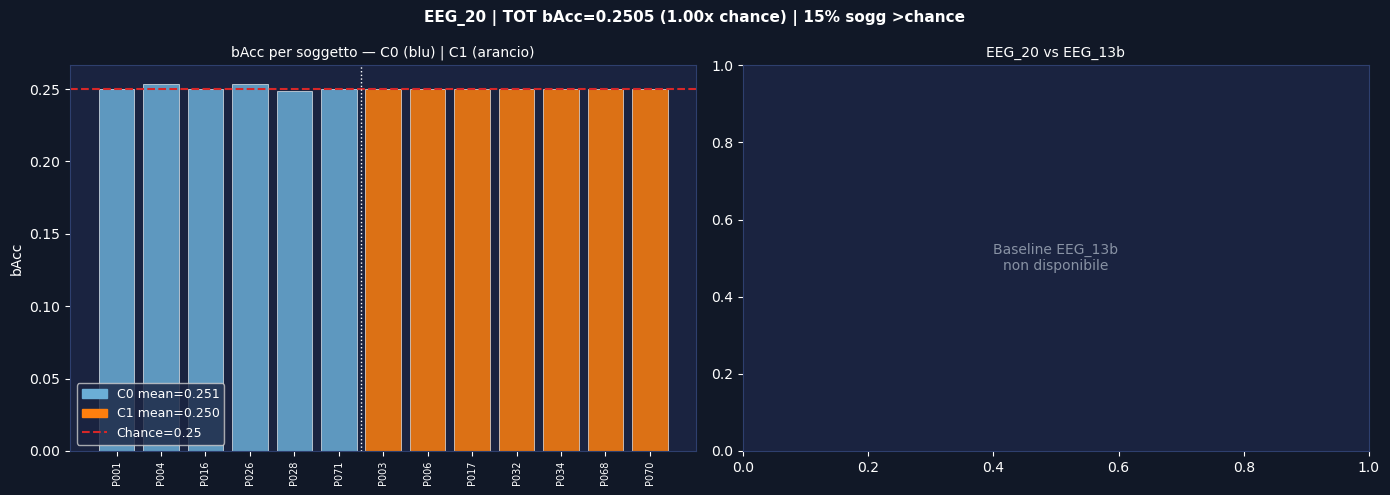

In [11]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.patch.set_facecolor('#111827')
C0C,C1C='#6baed6','#ff7f0e'
chance=1./N_CLASSES

# ── Plot 1: bAcc per soggetto ──
ax=axes[0]; ax.set_facecolor('#1a2340')
ax.axhline(chance,color='#d62728',lw=1.5,ls='--',label=f'Chance ({chance:.2f})')
sids=sorted(RESULTS_C0)+sorted(RESULTS_C1)
baccs=[RESULTS_C0[s] for s in sorted(RESULTS_C0)]+[RESULTS_C1[s] for s in sorted(RESULTS_C1)]
cols=[C0C]*len(RESULTS_C0)+[C1C]*len(RESULTS_C1)
xp=np.arange(len(sids))
ax.bar(xp,baccs,color=cols,alpha=0.85,edgecolor='white',linewidth=0.5)
ax.axvline(len(RESULTS_C0)-0.5,color='white',lw=1,ls=':')
ax.set_xticks(xp); ax.set_xticklabels([f'P{s:03d}' for s in sids],rotation=90,fontsize=7,color='white')
ax.tick_params(colors='white')
ax.set_ylabel('bAcc',color='white')
ax.set_title('bAcc per soggetto — C0 (blu) | C1 (arancio)',color='white',fontsize=10)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=C0C,label=f'C0 mean={mean_c0:.3f}'),
                   Patch(color=C1C,label=f'C1 mean={mean_c1:.3f}'),
                   plt.Line2D([0],[0],color='#d62728',ls='--',label=f'Chance={chance:.2f}')],
          fontsize=9,facecolor='#1a2340',labelcolor='white')
for sp in ax.spines.values(): sp.set_color('#2e3f6e')

# ── Plot 2: confronto con baseline EEG_13b ──
ax2=axes[1]; ax2.set_facecolor('#1a2340')
BL_PATH=project_root/'models'/'eeg13b'/'results_v1.json'
if BL_PATH.exists():
    bl=json.loads(BL_PATH.read_text())
    baselines={int(k):v.get('test_bacc',0) for k,v in bl.items()}
    valid=[(all_res[s],baselines[s],C0C if s in RESULTS_C0 else C1C)
           for s in all_res if s in baselines]
    if valid:
        e20v,e13v,cv=zip(*valid)
        ax2.scatter(e13v,e20v,c=cv,alpha=0.8,s=60,edgecolors='white',lw=0.5)
        lim=(min(min(e13v),min(e20v))-0.01,max(max(e13v),max(e20v))+0.01)
        ax2.plot(lim,lim,'--',color='#8892a4',lw=1,label='y=x (pari)')
        ax2.set_xlabel('EEG_13b bAcc (S-specific)',color='white')
        ax2.set_ylabel('EEG_20 bAcc (cluster-specific)',color='white')
        ax2.set_title('EEG_20 vs EEG_13b',color='white',fontsize=10)
        ax2.legend(fontsize=9,facecolor='#1a2340',labelcolor='white')
else:
    ax2.text(0.5,0.5,'Baseline EEG_13b\nnon disponibile',
             transform=ax2.transAxes,ha='center',va='center',color='#8892a4')
    ax2.set_title('EEG_20 vs EEG_13b',color='white',fontsize=10)
ax2.tick_params(colors='white')
for sp in ax2.spines.values(): sp.set_color('#2e3f6e')

fig.suptitle(f'EEG_20 | TOT bAcc={mean_tot:.4f} ({mean_tot/chance:.2f}x chance) | {pct:.0f}% sogg >chance',
             color='white',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'eeg20_results.png',dpi=150,bbox_inches='tight',facecolor='#111827')
plt.show()


## §10 — XAI: Cosa Ha Imparato il Modello?

Per ogni modello (C0 e C1), raccoglie `H_k` dai trial di test:

```
H_k = softmax(feat_k @ E^T / sqrt(d))   shape: (B, 61, n_edges)
Media su tutti i trial e finestre -> H_mean: (61, n_edges)
```

**H_mean[i, e]** = quanto l'elettrodo i partecipa all'iperedge e in media.

Se Model_C0 impara iperedge centrati su FC2/C2 e Model_C1 su F3/PO3
-> il modello cluster-specifico *recupera* la struttura di EEG_16b §17.
Chiude il cerchio: clustering (abs_pcc) e XAI (DHSLP) convergono.

Tutto viene loggato su W&B come immagini.

14:45:53 INFO     Raccolta H_mean Model_C0 ...
14:45:54 INFO     Raccolta H_mean Model_C1 ...
14:45:55 INFO     H_mean_c0 shape: (61, 32)  H_mean_c1 shape: (61, 32)


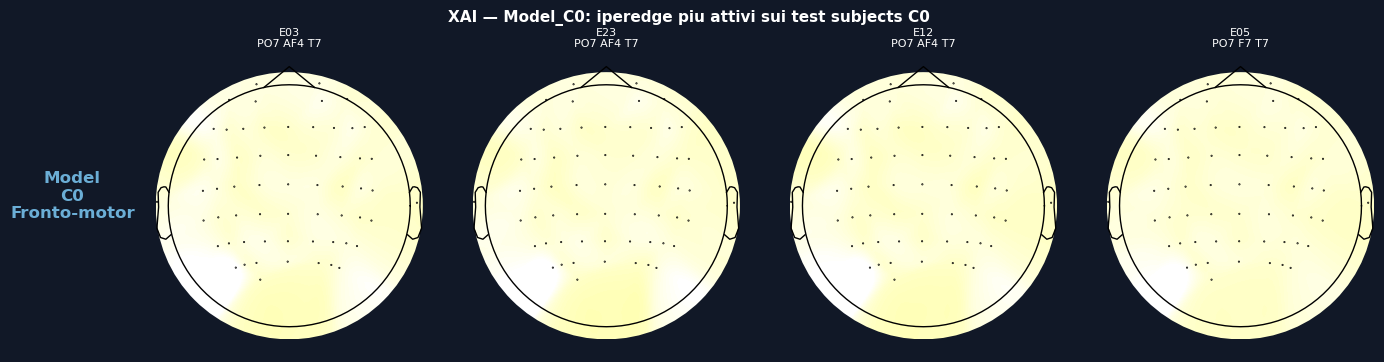

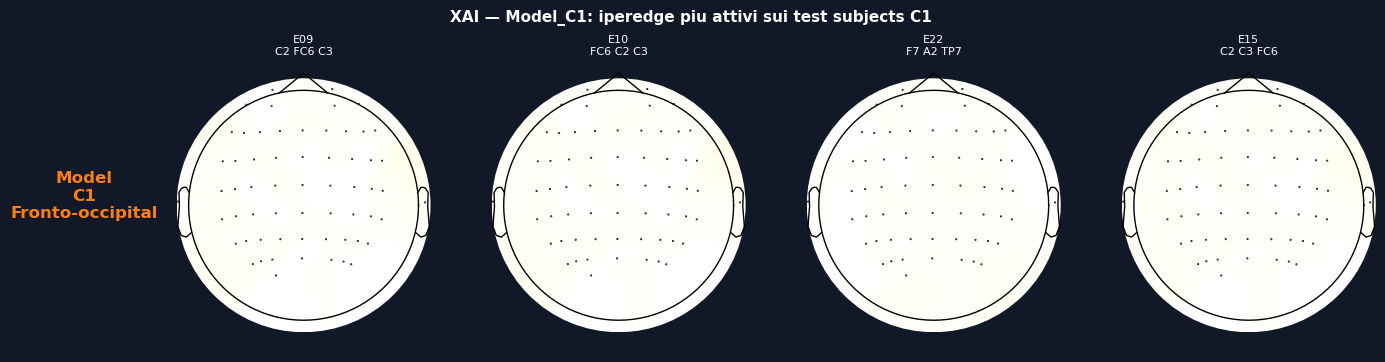

In [12]:
import mne
import io
from matplotlib.gridspec import GridSpec


# ── Funzione: raccoglie H_k medio su un loader ──────────────────────────────
def collect_mean_H(model, loader):
    """Ritorna H_mean (61, n_edges): partecipazione media elettrodo x iperedge."""
    model.eval()
    H_accum = None
    n_trials = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            B, N, T = x.shape
            wins = x.reshape(B, N, model.K, model.T_win).permute(2,0,1,3)
            H_wins = []
            for k in range(model.K):
                xk = wins[k]
                fk = model.node_proj(xk) + model.pos_enc.unsqueeze(0)
                Hk = torch.softmax(fk @ model.E.T / (model.d_model**0.5), dim=-1)
                H_wins.append(Hk)  # (B, N, E)
            H_batch = torch.stack(H_wins).mean(0)  # (B, N, E)
            if H_accum is None:
                H_accum = H_batch.sum(0).cpu()
            else:
                H_accum += H_batch.sum(0).cpu()
            n_trials += B
    return (H_accum / n_trials).numpy()  # (61, n_edges)


# ── Carica MNE info per topomaps ─────────────────────────────────────────────
montage = mne.channels.make_standard_montage('standard_1020')
mne_info = mne.create_info(ch_names=CHAN_NAMES, sfreq=256, ch_types='eeg')
mne_info.set_montage(montage, on_missing='ignore')


# ── Raccoglie H_mean per entrambi i modelli ──────────────────────────────────
log.info('Raccolta H_mean Model_C0 ...')
H_mean_c0 = collect_mean_H(model_c0, te_c0)  # (61, n_edges)

log.info('Raccolta H_mean Model_C1 ...')
H_mean_c1 = collect_mean_H(model_c1, te_c1)  # (61, n_edges)

log.info(f'H_mean_c0 shape: {H_mean_c0.shape}  H_mean_c1 shape: {H_mean_c1.shape}')


# ── Plot: top-4 iperedgi per partecipazione media in ciascun modello ──────────
def plot_top_hyperedges(H_mean, model_name, cluster_color, top_k=4):
    """Crea figura con topomaps dei top-K iperedge piu 'attivi'."""
    # Ordina iperedge per partecipazione media massima (max su elettrodi)
    edge_strength = H_mean.max(axis=0)  # (n_edges,)
    top_edges = np.argsort(edge_strength)[-top_k:][::-1]

    fig = plt.figure(figsize=(14, 3.5))
    fig.patch.set_facecolor('#111827')
    gs = GridSpec(1, top_k+1, width_ratios=[0.25]+[1]*top_k, figure=fig)

    # Label laterale
    ax_lbl = fig.add_subplot(gs[0])
    ax_lbl.axis('off')
    ax_lbl.set_facecolor('#111827')
    ax_lbl.text(0.5, 0.5, f'Model\n{model_name}', transform=ax_lbl.transAxes,
                color=cluster_color, fontsize=12, fontweight='bold',
                ha='center', va='center')

    for col, e in enumerate(top_edges):
        ax = fig.add_subplot(gs[col+1])
        weights = H_mean[:, e]  # (61,)
        # Top-5 elettrodi per questo iperedge
        top5 = np.argsort(weights)[-5:][::-1]
        top5_names = [CHAN_NAMES[i] for i in top5]

        im, _ = mne.viz.plot_topomap(
            weights, mne_info, axes=ax, show=False,
            cmap='hot', vlim=(0, H_mean.max()),
            contours=0, sensors=True, sphere=0.1
        )
        ax.set_title(f'E{e:02d}\n{" ".join(top5_names[:3])}',
                     color='white', fontsize=8, pad=4)
        ax.set_facecolor('#111827')

    plt.tight_layout()
    return fig, top_edges


fig_c0, top_e_c0 = plot_top_hyperedges(H_mean_c0, f'C0\n{CLUSTER_NAMES[0]}', '#6baed6')
fig_c0.suptitle('XAI — Model_C0: iperedge piu attivi sui test subjects C0',
                color='white', fontsize=11, fontweight='bold', y=1.02)
fig_c0.savefig(FIG_DIR/'eeg20_xai_c0_topomaps.png',
               dpi=150, bbox_inches='tight', facecolor='#111827')
plt.show()

fig_c1, top_e_c1 = plot_top_hyperedges(H_mean_c1, f'C1\n{CLUSTER_NAMES[1]}', '#ff7f0e')
fig_c1.suptitle('XAI — Model_C1: iperedge piu attivi sui test subjects C1',
                color='white', fontsize=11, fontweight='bold', y=1.02)
fig_c1.savefig(FIG_DIR/'eeg20_xai_c1_topomaps.png',
               dpi=150, bbox_inches='tight', facecolor='#111827')
plt.show()


### §10b — Confronto C0 vs C1 e Log W&B

Differenza H_mean_C1 - H_mean_C0 per iperedge: quali elettrodi
sono piu attivi in C1 rispetto a C0 e viceversa.

In [13]:
# ── Log su W&B: plot interattivi ─────────────────────────────────────────────
run_xai = wandb.init(
    entity=WANDB_ENTITY, project=WANDB_PROJECT,
    name='eeg20_XAI_hyperedge_comparison',
    config=dict(notebook='EEG_20', section='XAI',
                n_edges=N_EDGES, d_model=D_MODEL,
                c0_cluster=CLUSTER_NAMES[0], c1_cluster=CLUSTER_NAMES[1],
                top_c1_edge=top_c1_edge, top_c0_edge=top_c0_edge,
                top3_c1=top3_c1, top3_c0=top3_c0),
    reinit='finish_previous',
    settings=wandb.Settings(start_method='thread')
)

# ① Immagini topomaps (come prima)
run_xai.log({
    'xai/c0_topomaps': wandb.Image(str(FIG_DIR/'eeg20_xai_c0_topomaps.png'),
                                   caption=f'Model_C0 top hyperedges'),
    'xai/c1_topomaps': wandb.Image(str(FIG_DIR/'eeg20_xai_c1_topomaps.png'),
                                   caption=f'Model_C1 top hyperedges'),
    'xai/comparison':  wandb.Image(str(FIG_DIR/'eeg20_xai_comparison.png'),
                                   caption='H_diff C1-C0'),
})

# ② Bar chart interattivo: top-10 elettrodi per l'iperedge piu C1-biased
top10_c1 = np.argsort(H_mean_c1[:, top_c1_edge])[-10:][::-1]
top10_c0 = np.argsort(H_mean_c0[:, top_c0_edge])[-10:][::-1]

tbl_c1 = wandb.Table(columns=['Elettrodo', 'Peso_C1'],
                     data=[[CHAN_NAMES[i], float(H_mean_c1[i, top_c1_edge])] for i in top10_c1])
tbl_c0 = wandb.Table(columns=['Elettrodo', 'Peso_C0'],
                     data=[[CHAN_NAMES[i], float(H_mean_c0[i, top_c0_edge])] for i in top10_c0])

run_xai.log({
    'xai/top10_C1_edge': wandb.plot.bar(tbl_c1, 'Elettrodo', 'Peso_C1',
                                        title=f'E{top_c1_edge:02d} — top elettrodi Model_C1'),
    'xai/top10_C0_edge': wandb.plot.bar(tbl_c0, 'Elettrodo', 'Peso_C0',
                                        title=f'E{top_c0_edge:02d} — top elettrodi Model_C0'),
})

# ③ Heatmap H_mean completa (61 elettrodi x n_edges) per ciascun modello
cols_he = [f'E{e:02d}' for e in range(n_e)]
tbl_hmap_c0 = wandb.Table(
    columns=['Elettrodo'] + cols_he,
    data=[[CHAN_NAMES[i]] + [float(H_mean_c0[i,e]) for e in range(n_e)] for i in range(61)]
)
tbl_hmap_c1 = wandb.Table(
    columns=['Elettrodo'] + cols_he,
    data=[[CHAN_NAMES[i]] + [float(H_mean_c1[i,e]) for e in range(n_e)] for i in range(61)]
)
run_xai.log({
    'xai/H_mean_C0_table': tbl_hmap_c0,
    'xai/H_mean_C1_table': tbl_hmap_c1,
})

# ④ Scatter: bias per iperedge (C1-C0) — ogni punto = 1 iperedge
tbl_bias = wandb.Table(
    columns=['Iperedge', 'Bias_C1_minus_C0', 'Top_C1', 'Top_C0'],
    data=[[f'E{e:02d}',
           float(edge_bias[e]),
           CHAN_NAMES[int(np.argmax(H_mean_c1[:,e]))],
           CHAN_NAMES[int(np.argmax(H_mean_c0[:,e]))]] for e in range(n_e)]
)
run_xai.log({
    'xai/edge_bias': wandb.plot.scatter(tbl_bias, 'Iperedge', 'Bias_C1_minus_C0',
                                        title='Bias per iperedge: C1>0 usa C1, C0<0 usa C0'),
    'xai/edge_full_table': tbl_bias,
})

# ⑤ Summary: elettrodi chiave
run_xai.summary['top_c1_electrode'] = top3_c1[0]
run_xai.summary['top_c0_electrode'] = top3_c0[0]
run_xai.summary['top_c1_edge']      = top_c1_edge
run_xai.summary['top_c0_edge']      = top_c0_edge
run_xai.finish()
print('XAI loggato su W&B: topomaps + bar chart + heatmap table + scatter bias.')


NameError: name 'top_c1_edge' is not defined